# Advanced Loan Approval Prediction — ML Model Development

This notebook develops, evaluates, compares, and saves classification models using the cleaned loan dataset prepared by the data team.

**Workflow:** Load data → Train/Test Split → Encoding & Scaling → Model Training → Evaluation → Model Comparison → Confusion Matrices → Final Model → Save Model → Test New Applicant

## 1. Import Libraries

In [1]:
import pathlib
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

pd.set_option('display.max_columns', None)

## 2. Load the Cleaned Dataset

The cleaned dataset is stored in `../data/cleaned_loan_data.csv` relative to this notebook.

In [2]:
DATA_PATH = pathlib.Path('../data/cleaned_loan_data.csv')

df = pd.read_csv(DATA_PATH)

print('Dataset loaded successfully.')
print('Dataset shape:', df.shape)

df.head()

Dataset loaded successfully.
Dataset shape: (614, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 3. Dataset Overview

In [3]:
print('Columns:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum())

Columns:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

Data types:
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

Missing values:
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64


## 4. Define Features and Target

`Loan_Status` is the target variable. The remaining 11 columns are used as input features.

In [4]:
X = df.drop('Loan_Status', axis=1)
y = df['Loan_Status']

print('Features:')
print(X.columns.tolist())

print('\nTarget:', y.name)

print('\nTarget distribution:')
print(y.value_counts())

print('\nTarget percentage:')
print((y.value_counts(normalize=True) * 100).round(2))

Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area']

Target: Loan_Status

Target distribution:
Loan_Status
Y    422
N    192
Name: count, dtype: int64

Target percentage:
Loan_Status
Y    68.73
N    31.27
Name: proportion, dtype: float64


## 5. Train/Test Split

A stratified 80/20 split is used so the class distribution is approximately preserved in both sets.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)
print('y_train:', y_train.shape)
print('y_test :', y_test.shape)

X_train: (491, 11)
X_test : (123, 11)
y_train: (491,)
y_test : (123,)


## 6. Define Numerical and Categorical Features

In [6]:
numerical_features = [
    'ApplicantIncome',
    'CoapplicantIncome',
    'LoanAmount',
    'Loan_Amount_Term',
    'Credit_History'
]

categorical_features = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area'
]

print('Numerical features:', numerical_features)
print('Categorical features:', categorical_features)

Numerical features: ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']
Categorical features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


## 7. Create the Preprocessing Pipeline

- Numerical features → `StandardScaler`
- Categorical features → `OneHotEncoder`

The preprocessing is placed inside each model pipeline to avoid data leakage.

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

print('Preprocessor created successfully.')

Preprocessor created successfully.


## 8. Create Classification Models

Three baseline classifiers are trained and compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest

In [8]:
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

decision_tree_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42))
])

random_forest_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(n_estimators=100, random_state=42))
])

print('All model pipelines created successfully.')

All model pipelines created successfully.


## 9. Train the Models

In [9]:
logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)
random_forest_model.fit(X_train, y_train)

print('All models trained successfully.')

All models trained successfully.


## 10. Generate Test Predictions

In [10]:
y_pred_logistic = logistic_model.predict(X_test)
y_pred_tree = decision_tree_model.predict(X_test)
y_pred_forest = random_forest_model.predict(X_test)

print('Predictions generated successfully.')

Predictions generated successfully.


## 11. Evaluate the Models

In [11]:
def evaluate_model(model_name, y_true, y_pred):
    return {
        'Model': model_name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, pos_label='Y'),
        'Recall': recall_score(y_true, y_pred, pos_label='Y'),
        'F1 Score': f1_score(y_true, y_pred, pos_label='Y')
    }

results = [
    evaluate_model('Logistic Regression', y_test, y_pred_logistic),
    evaluate_model('Decision Tree', y_test, y_pred_tree),
    evaluate_model('Random Forest', y_test, y_pred_forest)
]

results_df = pd.DataFrame(results)
results_df.sort_values('F1 Score', ascending=False).reset_index(drop=True)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.861789,0.840000,0.988235,0.908108
1,Random Forest,0.821138,0.846154,0.905882,0.875000
2,Decision Tree,0.756098,0.823529,0.823529,0.823529


## 12. Model Comparison Visualization

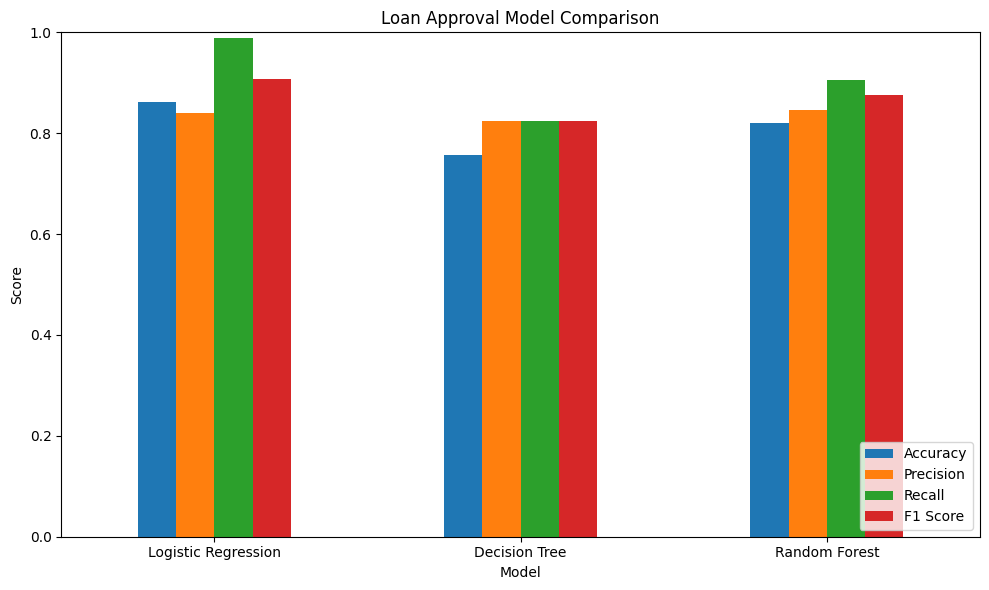

In [12]:
plot_df = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1 Score']]

plot_df.plot(kind='bar', figsize=(10, 6))
plt.title('Loan Approval Model Comparison')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 13. Confusion Matrices

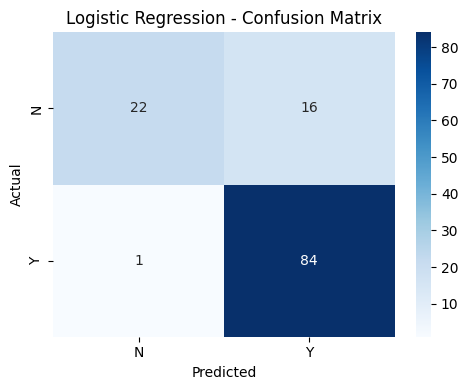

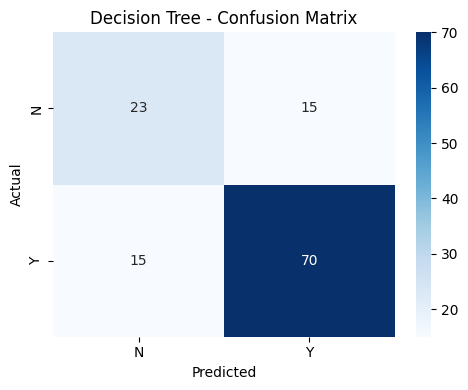

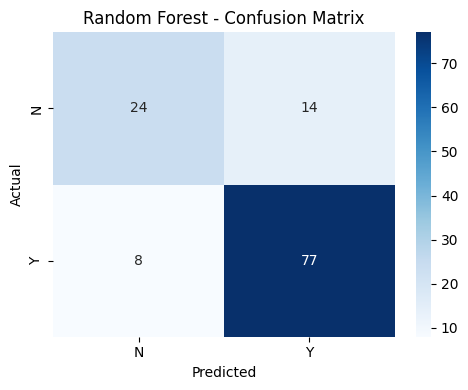

In [13]:
model_predictions = {
    'Logistic Regression': y_pred_logistic,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_forest
}

for name, predictions in model_predictions.items():
    cm = confusion_matrix(y_test, predictions, labels=['N', 'Y'])

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['N', 'Y'],
        yticklabels=['N', 'Y']
    )
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

## 14. Final Model Classification Report

Based on the current test-set comparison, Logistic Regression is used as the final candidate because it has the highest accuracy, recall, and F1 score among the three tested models on this split.

In [14]:
final_model = logistic_model
final_predictions = y_pred_logistic

print('Logistic Regression - Classification Report')
print(
    classification_report(
        y_test,
        final_predictions,
        target_names=['Not Approved', 'Approved']
    )
)

Logistic Regression - Classification Report
              precision    recall  f1-score   support

Not Approved       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123



## 15. Save the Final Model

The complete pipeline is saved so the backend can send raw applicant fields directly to it. The pipeline automatically performs the same encoding and scaling used during training.

In [15]:
MODEL_DIR = pathlib.Path('models')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PIPELINE_PATH = MODEL_DIR / 'loan_approval_model.pkl'
PREPROCESSOR_PATH = MODEL_DIR / 'loan_approval_preprocessor.pkl'
CLASSIFIER_PATH = MODEL_DIR / 'loan_approval_classifier.pkl'
RESULTS_PATH = MODEL_DIR / 'model_comparison.csv'

joblib.dump(final_model, PIPELINE_PATH)
joblib.dump(final_model.named_steps['preprocessor'], PREPROCESSOR_PATH)
joblib.dump(final_model.named_steps['model'], CLASSIFIER_PATH)
results_df.to_csv(RESULTS_PATH, index=False)

print('Files saved successfully:')
print(PIPELINE_PATH)
print(PREPROCESSOR_PATH)
print(CLASSIFIER_PATH)
print(RESULTS_PATH)

Files saved successfully:
models\loan_approval_model.pkl
models\loan_approval_preprocessor.pkl
models\loan_approval_classifier.pkl
models\model_comparison.csv


## 16. Test the Saved Model with a New Applicant

This checks that the saved pipeline can make a prediction from raw feature values in the same format that the backend will receive.

In [16]:
loaded_model = joblib.load(PIPELINE_PATH)

new_applicant = pd.DataFrame([{
    'Gender': 'Male',
    'Married': 'Yes',
    'Dependents': '0',
    'Education': 'Graduate',
    'Self_Employed': 'No',
    'ApplicantIncome': 5000,
    'CoapplicantIncome': 2000,
    'LoanAmount': 150,
    'Loan_Amount_Term': 360,
    'Credit_History': 1.0,
    'Property_Area': 'Urban'
}])

prediction = loaded_model.predict(new_applicant)[0]
probabilities = loaded_model.predict_proba(new_applicant)[0]

print('Predicted Loan Status:', prediction)
print(f'Probability of Not Approved (N): {probabilities[0]:.2%}')
print(f'Probability of Approved (Y): {probabilities[1]:.2%}')

Predicted Loan Status: Y
Probability of Not Approved (N): 20.37%
Probability of Approved (Y): 79.63%


## 17. ML Handoff

The final model pipeline is now ready for backend integration.

### Output
- `models/loan_approval_model.pkl` — complete preprocessing + Logistic Regression pipeline
- `models/loan_approval_preprocessor.pkl` — preprocessing component
- `models/loan_approval_classifier.pkl` — Logistic Regression classifier
- `models/model_comparison.csv` — model evaluation results

### Backend flow
`Applicant Input → Saved Pipeline → Prediction → FastAPI → Streamlit`